## Data Cleaning 😥

In [1]:
import pandas as pd 
import numpy as np

In [2]:
df = pd.read_excel("Reports.xlsx")

In [3]:
df.head(5)

,Full Name,Age,Email,Join Date,Department,Salary
0,ALICE JOHNSON,NaN,annamarie@domain,2023-01-10,finance,NaN
1,Li Wei,thirty,ALICE@GMAIL.COM,not a date,HR,unknown
2,Oluwaseun Bello,40,john@example.com,2022/12/01,NaN,75k
3,Li Wei,40,annamarie@domain,not a date,finance,100000
4,Li Wei,NaN,liwei@example,2023-01-10,HR,unknown


In [4]:
df.shape

(5000, 6)

In [5]:
df.describe()

,Full Name,Age,Email,Join Date,Department,Salary
count,5000,3976,3594,3518,3896,3733
unique,6,8,5,5,7,6
top,John Smith,60,liwei@example,2022/12/01,Finance,120000
freq,870,555,765,723,592,658


In [6]:
# removing duplicates
df = df.drop_duplicates().reset_index(drop=True)

In [8]:
#standardizing full name
df["Full Name"] = df["Full Name"].str.strip().str.replace(r'\s+','',regex=True).str.title()

In [9]:
# Handling inconsistencies in Age
df["Age"] =df["Age"].replace({'thirty':30})
df["Age"] = pd.to_numeric(df["Age"],errors='coerce')

In [10]:
# standardizing emails
df["Email"] = df["Email"].str.lower().str.replace('@@','@',regex=False)

In [11]:
# normalizing the date
df["Join Date"] = pd.to_datetime(df["Join Date"],errors="coerce")

In [12]:
# standardizing the departments
df["Department"] = df["Department"].str.strip().str.title()

In [13]:
# handling inconsistency in the salary 
def clean_salary(value):
    if pd.isna(value) or str(value).lower() == "unknown":
        return np.nan
    value = str(value).replace(',','').lower()
    if "k" in value:
        return float(value.replace('k','')) * 1000
    try:
        return float(value)
    except ValueError:
       return np.nan 

In [14]:
df["Salary"] = df["Salary"].apply(clean_salary)

In [32]:
df.head(5)


,Full Name,Age,Email,Join Date,Department,Salary
0,Alicejohnson,NaN,annamarie@domain,2023-01-10,Finance,NaN
1,Liwei,30.0,alice@gmail.com,NaT,Hr,NaN
2,Oluwaseunbello,40.0,john@example.com,NaT,NaN,75000.0
3,Liwei,40.0,annamarie@domain,NaT,Finance,100000.0
4,Liwei,NaN,liwei@example,2023-01-10,Hr,NaN


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns 
sns.set_theme(style = "whitegrid")

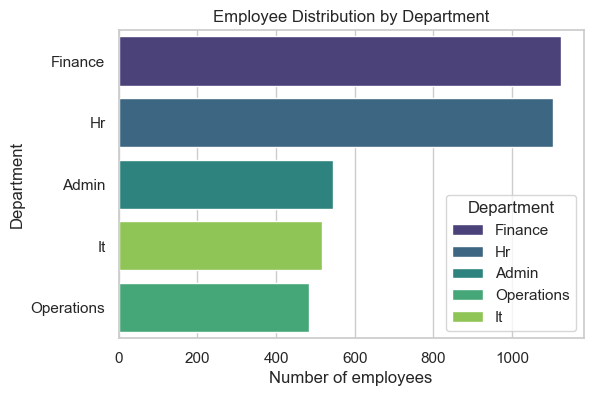

In [19]:
# Department counts
plt.figure(figsize=(6,4))
sns.countplot(data = df,y= "Department",order=df["Department"].value_counts().index,
              palette= "viridis", hue = "Department",legend = "auto")
plt.title("Employee Distribution by Department")
plt.xlabel("Number of employees")
plt.show()

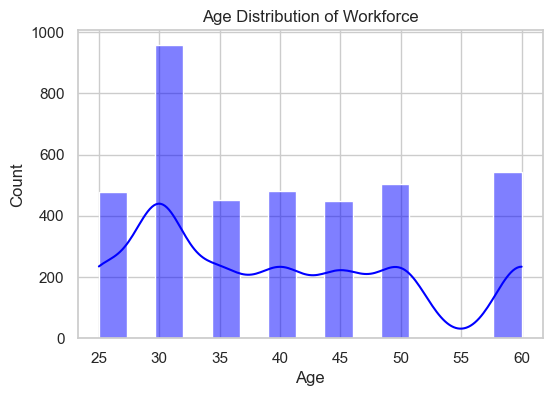

In [22]:
# Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df["Age"].dropna(),bins=15,
            kde=True,color = 'blue')
plt.title("Age Distribution of Workforce")
plt.xlabel("Age")
plt.show()

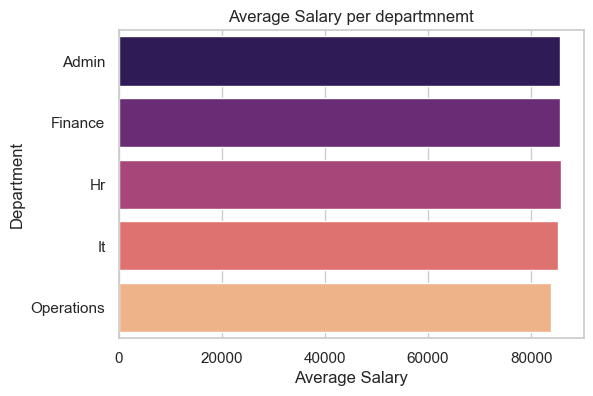

In [29]:
# Average salary by department
plt.figure(figsize=(6,4))
AvgSalary = df.groupby("Department")["Salary"].mean()
sns.barplot(x= AvgSalary.values, y=AvgSalary.index,hue=AvgSalary.index,palette='magma')
plt.title("Average Salary per departmnemt")
plt.xlabel("Average Salary")
plt.show()          

In [33]:
df.to_excel("CleanReport.xlsx")